# 02 — Continuously Invested Trend Baseline

**Development validation only. The sealed holdout is not loaded or evaluated.**

This is a deliberately transparent benchmark, not a finished strategy. It combines eight causal trend measures, sizes with trailing exponentially weighted/shrunk covariance, keeps both long and short books active, delays implementation by one session, charges 3.5 bps per one-way turnover, and applies the agreed drawdown controls.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'outputs' else Path.cwd()
PORT = ROOT / 'data/processed/portfolios'
summary = pd.read_csv(PORT / 'development_trend_walk_forward_summary.csv')
folds = pd.read_csv(ROOT / 'outputs/development_walk_forward_folds.csv')
summary

,fold,sessions,annualized_return,annualized_volatility,sharpe,maximum_drawdown,average_gross,average_net,average_daily_turnover,strategy
0,1,63,-0.186021,0.075461,-2.465141,-0.042516,1.020364,5.507059e-20,0.108056,plain_trend
1,2,63,-0.023531,0.092941,-0.253187,-0.058710,0.898451,3.965082e-18,0.119561,plain_trend
2,3,63,0.101316,0.124313,0.815009,-0.047189,0.726047,-4.625929e-18,0.132086,plain_trend
3,4,37,-0.092194,0.056080,-1.643953,-0.021560,0.916782,-2.229354e-17,0.139467,plain_trend
4,1,63,-0.201711,0.079790,-2.528024,-0.046353,1.056932,-1.365751e-17,0.111174,regime_aware_trend
5,2,63,-0.032026,0.093615,-0.342099,-0.062957,0.870431,7.930164e-18,0.115471,regime_aware_trend
6,3,63,0.115662,0.093555,1.236299,-0.033812,0.664220,-8.040306e-18,0.133507,regime_aware_trend
7,4,37,-0.100492,0.056894,-1.766291,-0.021641,0.920212,3.481168e-18,0.139661,regime_aware_trend


## Signal definition

The forecast equally combines 20/60-session standardized return, price versus 20/60-session moving averages, 5–20 and 10–60 EMA gaps, and 20/60-session linear-regression slopes. Every component is bounded; no return labels are used to select or optimize weights.

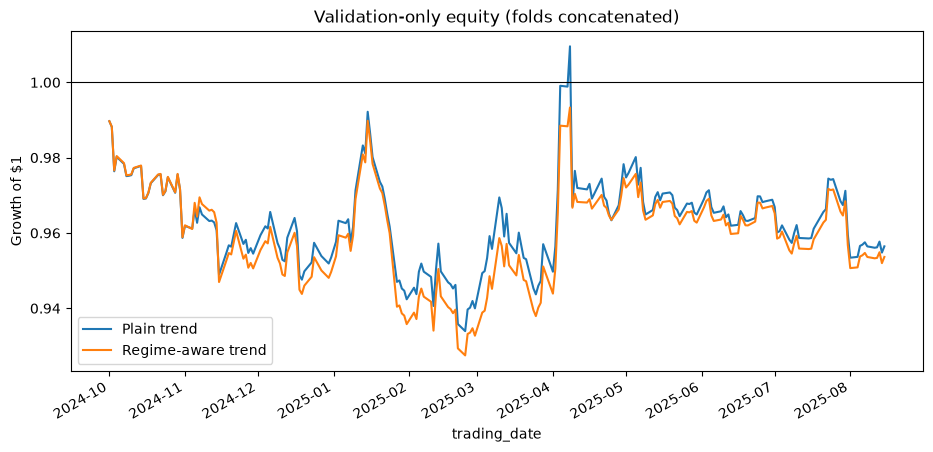

In [2]:
plain = pd.read_parquet(PORT / 'development_trend_returns.parquet')['net_return']
aware = pd.read_parquet(PORT / 'development_regime_trend_returns.parquet')['net_return']
mask = pd.Series(False, index=plain.index)
for row in folds.itertuples():
    mask.loc[pd.Timestamp(row.validation_start):pd.Timestamp(row.validation_end)] = True
equity = pd.DataFrame({'Plain trend': (1 + plain[mask]).cumprod(), 'Regime-aware trend': (1 + aware[mask]).cumprod()})
ax = equity.plot(figsize=(11, 5), title='Validation-only equity (folds concatenated)')
ax.axhline(1.0, color='black', lw=0.8)
ax.set_ylabel('Growth of $1')
plt.show()

In [3]:
weights = pd.read_parquet(PORT / 'development_trend_target_weights.parquet')
exposure = pd.DataFrame({'gross': weights.abs().sum(axis=1), 'net': weights.sum(axis=1)})
exposure.loc[mask].describe(percentiles=[.05, .5, .95])

,gross,net
count,226.000000,2.260000e+02
mean,1.041104,-5.921855e-18
std,0.436682,7.098866e-17
min,0.329126,-2.220446e-16
5%,0.417215,-1.110223e-16
50%,1.039534,0.000000e+00
95%,1.961134,1.110223e-16
max,2.000000,2.220446e-16


## Decision

The baseline does **not** graduate as a strategy: three of four folds are negative. The regime overlay improves the third fold but does not repair the broad instability. This is evidence to continue the planned sequence—not permission to tune on the holdout.

Next: build the short-term reversal sleeve independently, then relationship/relative-value and lead–lag sleeves. Only development-fold-stable sleeves may enter portfolio combination.